In [659]:
import json
import uuid
import base64
import qrcode
import base58
from typing import Optional, List
import requests
from IPython import display
from typing import Optional, List, Union  # Added Union
from didcomm.message import Message, FromPrior
from didcomm.pack_encrypted import pack_encrypted, PackEncryptedConfig, PackEncryptedResult
from didcomm.common.types import DID, VerificationMethodType, VerificationMaterial, VerificationMaterialFormat
from didcomm.did_doc.did_doc import DIDDoc, VerificationMethod, DIDCommService
from didcomm.common.resolvers import ResolversConfig
from didcomm.did_doc.did_resolver import DIDResolver
from didcomm.secrets.secrets_resolver_demo import SecretsResolverDemo
from peerdid.core.did_doc_types import DIDCommServicePeerDID
from peerdid import peer_did
from peerdid.types import (
    VerificationMaterialAuthentication,
    VerificationMethodTypeAuthentication,
    VerificationMaterialAgreement,
    VerificationMethodTypeAgreement,
    VerificationMaterialFormatPeerDID,
)
from didcomm.secrets.secrets_util import (
    generate_x25519_keys_as_jwk_dict,
    generate_ed25519_keys_as_jwk_dict,
    jwk_to_secret,
)


In [660]:
secrets_resolver = SecretsResolverDemo()

In [661]:
# Define resolver profiles (customize as needed)
class PeerDIDResolverProfile:
    DEFAULT = "default"
    ROOTS_ID = "roots_id"


class DIDResolverPeerDID(DIDResolver):
    def __init__(self, peer_did_resolver_profile=PeerDIDResolverProfile.DEFAULT):
        self.peer_did_resolver_profile = peer_did_resolver_profile

    async def resolve(self, did: DID) -> DIDDoc:
        """Resolves a PeerDID into a DIDDoc with formatted services and key IDs."""
        if not did or not isinstance(did, str):
            raise ValueError("Invalid DID: DID must be a non-empty string")

        try:
            # Use custom logic to resolve the DID
            did_doc_form = self._resolve_did_custom(did)
            
            # Convert the did_doc to JSON format
            did_doc = did_doc_form
            print("did_doc in JSON format:")
            print(did_doc)

            # Construct the DID document in the correct format
            return DIDDoc(
                id=did_doc["id"],
                verification_methods=[
                    VerificationMethod(
                        id=vm["id"],
                        type="Multikey",
                        controller=vm["controller"],
                        verification_material=VerificationMaterial(
                            format=VerificationMaterialFormat.MULTIBASE,
                            value=vm["publicKeyMultibase"],
                        ),
                    )
                    for vm in did_doc["verificationMethod"]
                ],
                
                service=[
                    {
                        "id": s["id"],
                        "type": s["type"],
                        "serviceEndpoint": s["serviceEndpoint"],
                    }
                    for s in did_doc["service"]
                ],
            )
        except Exception as e:
            raise ValueError(f"Failed to resolve DID {did}: {str(e)}")
            
            
    def _resolve_did_custom(self, did: str) -> dict:
        """
        Custom method to resolve a Peer DID into a DID document (DIDDoc).
        This implementation parses the Peer DID and constructs a DID document.
        """
        if not did.startswith("did:peer:"):
            raise ValueError(f"Invalid Peer DID: {did}")

        # Split the DID into parts
        parts = did.split(":")
        if len(parts) < 3:
            raise ValueError(f"Invalid Peer DID format: {did}")

        # Extract the method and method_specific_id
        method = parts[1]
        method_specific_id = ":".join(parts[2:])  # Handle method_specific_id with colons

        # Create the base DID document structure
        did_doc = {
            "@context": [
                "https://www.w3.org/ns/did/v1",
                "https://w3id.org/security/multikey/v1",
            ],
            "id": did,
            "verificationMethod": [],
            "keyAgreement": [],
            "authentication": [],
            "assertionMethod": [],
            "service": []
        }

        # Resolve the DID based on the algorithm
        if method_specific_id.startswith("0"):
            return self._resolve_numalgo_0(did, method_specific_id,)
        elif method_specific_id.startswith("2"):
            return self._resolve_numalgo_2(did, method_specific_id, did_doc)
        else:
            raise ValueError(f"Unsupported Peer DID algorithm: {method_specific_id}")

    def _resolve_numalgo_0(self, did: str, method_specific_id: str) -> dict:
        """
        Resolves a Peer DID using numalgo 0 (inception key only).
        """
        # Extract the public key from the method_specific_id
        public_key_multibase = method_specific_id[1:]  # Remove the algorithm prefix

        # Create the base DID document structure
        did_doc = {
            "@context": [
                "https://www.w3.org/ns/did/v1",
                "https://w3id.org/security/multikey/v1",
            ],
            "id": did,
            "verificationMethod": [],
            "keyAgreement": [],
            "authentication": [],
            "assertionMethod": [],
            "service": []
        }

        # Add the verification method
        key_id = f"{did}#key-1"
        did_doc["verificationMethod"].append({
            "id": key_id,
            "type": "Multikey",
            "controller": did,
            "publicKeyMultibase": public_key_multibase,
        })

        # Populate keyAgreement and authentication
        did_doc["keyAgreement"].append(key_id)
        did_doc["authentication"].append(key_id)
        did_doc["assertionMethod"].append(key_id)

        return did_doc
    
    def _resolve_numalgo_2(self, did: str, method_specific_id: str, did_doc: dict) -> dict:
        """
        Resolves a Peer DID using numalgo 2 (multiple keys and/or service).
        """
        # Ensure the necessary keys are in the did_doc
        if "verificationMethod" not in did_doc:
            did_doc["verificationMethod"] = []
        if "service" not in did_doc:
            did_doc["service"] = []
        if "authentication" not in did_doc:
            did_doc["authentication"] = []
        if "assertionMethod" not in did_doc:
            did_doc["assertionMethod"] = []
        if "keyAgreement" not in did_doc:
            did_doc["keyAgreement"] = []

        # Split the method_specific_id into parts
        parts = method_specific_id.split(".")
        verification_methods = []
        services = []

        for part in parts:
            if part.startswith(("E", "V", "A")):  # Check for any cryptographic key
                key_type = part[0]
                key_value = part[1:]  # Extract the key value
                key_id = f"{did}#key-{len(verification_methods) + 1}"

                # Add the verification method
                verification_methods.append({
                    "id": key_id,
                    "type": "Multikey",
                    "controller": did,
                    "publicKeyMultibase": key_value,
                })

                # Populate keyAgreement, authentication, or assertionMethod
                if key_type == "V":
                    did_doc["authentication"].append(key_id)
                elif key_type == "A":
                    did_doc["assertionMethod"].append(key_id)
                elif key_type == "E":
                    did_doc["keyAgreement"].append(key_id)

            elif part.startswith("S"):  # Handle the service part
                try:
                    # Decode base64 and check if the result is valid JSON
                    decoded_data = base64.urlsafe_b64decode(part[1:] + "===").decode("utf-8")
                    service_data = json.loads(decoded_data)
                    # Ensure the service data has the expected structure
                    if "t" in service_data and "s" in service_data:
                        services.append({
                            "id": f"{did}#didcomm",
                            "type": "DIDCommMessaging",  # Map "dm" to "DIDCommMessaging"
                            "serviceEndpoint": {
                                "uri": service_data["s"]["uri"],
                                "routingKeys": service_data["s"].get("r", []),
                                "accept": service_data["s"].get("a", []),
                            },
                        })
                    else:
                        print(f"Invalid service data structure: {service_data}")
                except (base64.binascii.Error, UnicodeDecodeError, json.JSONDecodeError) as e:
                    # If there's an error decoding, log it or skip the service part
                    print(f"Failed to decode or parse service data: {e}")

        # Add verification methods and services to the DID document
        did_doc["verificationMethod"].extend(verification_methods)
        did_doc["service"].extend(services)

        return did_doc

In [675]:
async def create_peer_did(
    auth_keys_count: int = 1,
    agreement_keys_count: int = 1,
    service_endpoint: Optional[str] = None,
    service_routing_keys: Optional[List[str]] = None,
) -> str:
    # 1. Generate keys in JWK format
    agreem_keys = [generate_x25519_keys_as_jwk_dict() for _ in range(agreement_keys_count)]
    auth_keys = [generate_ed25519_keys_as_jwk_dict() for _ in range(auth_keys_count)]

    # 2. Prepare the keys for peer DID lib
    agreem_keys_peer_did = [
        VerificationMaterialAgreement(
            type=VerificationMethodTypeAgreement.JSON_WEB_KEY_2020,
            format=VerificationMaterialFormatPeerDID.JWK,
            value=k[1]["x"],  # Use the raw public key (x-coordinate for X25519)
        )
        for k in agreem_keys
    ]
    auth_keys_peer_did = [
        VerificationMaterialAuthentication(
            type=VerificationMethodTypeAuthentication.JSON_WEB_KEY_2020,
            format=VerificationMaterialFormatPeerDID.JWK,
            value=k[1]["x"],  # Use the raw public key (x-coordinate for Ed25519)
        )
        for k in auth_keys
    ]

    # 3. Generate service
    service = None
    if service_endpoint:
        service_data = {
            "t": "dm",  # Type (DIDCommMessaging)
            "s": {
                "uri": service_endpoint,
                "r": service_routing_keys if service_routing_keys else [],  # Routing keys
                "a": ["didcomm/v2"],  # Accept
            },
        }
        service = json.dumps(service_data)

    # 4. Construct the method_specific_id for numalgo 0 or numalgo 2
    if len(auth_keys_peer_did) == 1 and not agreem_keys_peer_did and not service:
        # Use numalgo 0
        # Decode the Base64 URL-safe x-coordinate to bytes
        decoded_x = base64.urlsafe_b64decode(auth_keys_peer_did[0].value + "===")
        # Encode the bytes using Base58 Bitcoin and prefix with 'z' (multibase)
        encoded_x = "z" + base58.b58encode(decoded_x).decode("utf-8")
        method_specific_id = f"0{encoded_x}"
        did = f"did:peer:{method_specific_id}"
    else:
        # Use numalgo 2
        method_specific_id = "2"
        for key in auth_keys_peer_did:
            # Decode the Base64 URL-safe x-coordinate to bytes
            decoded_x = base64.urlsafe_b64decode(key.value + "===")
            # Encode the bytes using Base58 Bitcoin and prefix with 'z' (multibase)
            encoded_x = "z" + base58.b58encode(decoded_x).decode("utf-8")
            method_specific_id += f".V{encoded_x}"  # Add authentication key
        for key in agreem_keys_peer_did:
            # Decode the Base64 URL-safe x-coordinate to bytes
            decoded_x = base64.urlsafe_b64decode(key.value + "===")
            # Encode the bytes using Base58 Bitcoin and prefix with 'z' (multibase)
            encoded_x = "z" + base58.b58encode(decoded_x).decode("utf-8")
            method_specific_id += f".E{encoded_x}"  # Add agreement key
        if service:
            # Encode the service data
            encoded_service = base64.urlsafe_b64encode(service.encode("utf-8")).decode("utf-8").rstrip("=")
            method_specific_id += f".S{encoded_service}"  # Add service
        did = f"did:peer:{method_specific_id}"

    # 5. Resolve the DID using your custom resolver
    resolver_roots = DIDResolverPeerDID()
    did_doc = resolver_roots._resolve_did_custom(did)
    #print(json.dumps(did_doc, indent=4))

    # Extract the key IDs from the resolved DID document
    auth_kids = [vm["id"] for vm in did_doc["verificationMethod"] if vm["id"] in did_doc["authentication"]]
    agreement_kids = [vm["id"] for vm in did_doc["verificationMethod"] if vm["id"] in did_doc["keyAgreement"]]

    # 6. Store the private keys with appropriate IDs
    for auth_key, kid in zip(auth_keys, did_doc["authentication"]):
            private_key = auth_key[0]
            private_key["kid"] = kid
            await secrets_resolver.add_key(jwk_to_secret(private_key))

    for agreem_key, kid in zip(agreem_keys, did_doc["keyAgreement"]):
            private_key = agreem_key[0]
            private_key["kid"] = kid
            await secrets_resolver.add_key(jwk_to_secret(private_key))

    return did

### Alice get OOB from Mediator

In [676]:
#oob_url = requests.get("http://127.0.0.1:8000/oob_url").text
oob_url = requests.get("https://didcomm-mediator.eudi-adorsys.com/oob_url").text

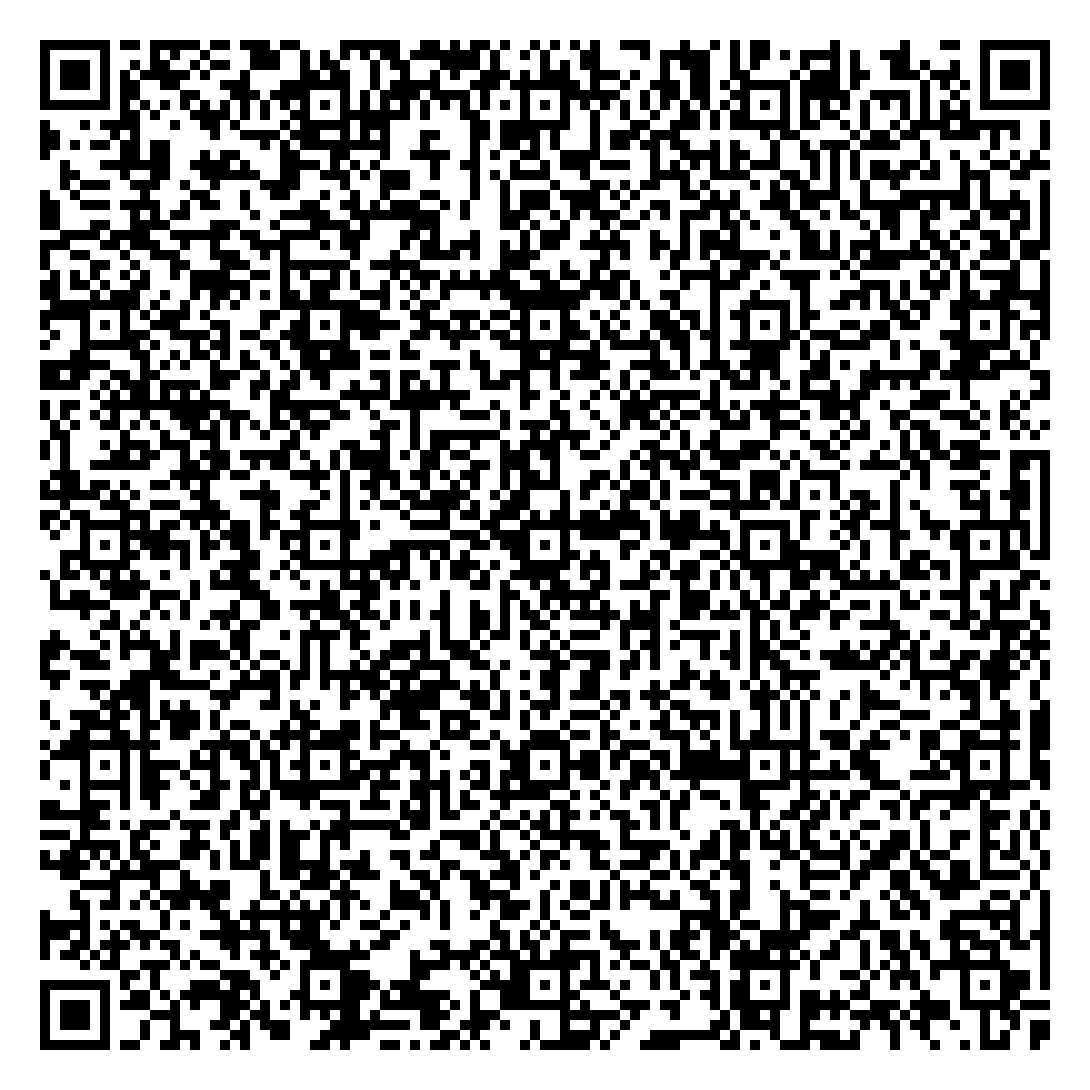

In [677]:
im = qrcode.make(oob_url)
im.save('qr.png')
display.Image('qr.png',width=500,height=500)

In [678]:
received_msg_encoded = oob_url.split("=")[1]
received_msg_decoded = json.loads(str(base64.urlsafe_b64decode(received_msg_encoded + "=="), "utf-8"))

alice_did_for_mediator = await create_peer_did(1, 1, "https://mediator.socious.io")
print("alice did for mediator:",alice_did_for_mediator )

alice did for mediator: did:peer:2.VzCG6STpsJGtMm7bramRrmZMreUpXLFdcJrjZ8HHSkJoWA.Ez24VCYtwCCfzvFdF15gRyBK5sPJbuDjXGm5BeivTAw3JB.SeyJ0IjogImRtIiwgInMiOiB7InVyaSI6ICJodHRwczovL21lZGlhdG9yLnNvY2lvdXMuaW8iLCAiciI6IFtdLCAiYSI6IFsiZGlkY29tbS92MiJdfX0


### Alice request mediate

In [679]:
alice_mediate_grant = Message(
    custom_headers = {"return_route": "all"},
    id = str(uuid.uuid4()),
    type = "https://didcomm.org/coordinate-mediation/2.0/mediate-request",
    body = {}
)

In [681]:
alice_mediate_grant_packed = await pack_encrypted(
    resolvers_config = ResolversConfig(
        secrets_resolver = secrets_resolver,
        did_resolver = DIDResolverPeerDID()
    ),
    message = alice_mediate_grant,
    frm = alice_did_for_mediator,
    to = received_msg_decoded["from"],
    sign_frm = None,
    pack_config = PackEncryptedConfig(protect_sender_id=False)
)

did_doc in JSON format:
{'@context': ['https://www.w3.org/ns/did/v1', 'https://w3id.org/security/multikey/v1'], 'id': 'did:peer:2.VzCG6STpsJGtMm7bramRrmZMreUpXLFdcJrjZ8HHSkJoWA.Ez24VCYtwCCfzvFdF15gRyBK5sPJbuDjXGm5BeivTAw3JB.SeyJ0IjogImRtIiwgInMiOiB7InVyaSI6ICJodHRwczovL21lZGlhdG9yLnNvY2lvdXMuaW8iLCAiciI6IFtdLCAiYSI6IFsiZGlkY29tbS92MiJdfX0', 'verificationMethod': [{'id': 'did:peer:2.VzCG6STpsJGtMm7bramRrmZMreUpXLFdcJrjZ8HHSkJoWA.Ez24VCYtwCCfzvFdF15gRyBK5sPJbuDjXGm5BeivTAw3JB.SeyJ0IjogImRtIiwgInMiOiB7InVyaSI6ICJodHRwczovL21lZGlhdG9yLnNvY2lvdXMuaW8iLCAiciI6IFtdLCAiYSI6IFsiZGlkY29tbS92MiJdfX0#key-1', 'type': 'Multikey', 'controller': 'did:peer:2.VzCG6STpsJGtMm7bramRrmZMreUpXLFdcJrjZ8HHSkJoWA.Ez24VCYtwCCfzvFdF15gRyBK5sPJbuDjXGm5BeivTAw3JB.SeyJ0IjogImRtIiwgInMiOiB7InVyaSI6ICJodHRwczovL21lZGlhdG9yLnNvY2lvdXMuaW8iLCAiciI6IFtdLCAiYSI6IFsiZGlkY29tbS92MiJdfX0', 'publicKeyMultibase': 'zCG6STpsJGtMm7bramRrmZMreUpXLFdcJrjZ8HHSkJoWA'}, {'id': 'did:peer:2.VzCG6STpsJGtMm7bramRrmZMreUpXLFdcJrjZ8HHSkJoWA

DIDUrlNotFoundError: No keyAgreement verification relationships are found for DID `did:peer:2.VzCG6STpsJGtMm7bramRrmZMreUpXLFdcJrjZ8HHSkJoWA.Ez24VCYtwCCfzvFdF15gRyBK5sPJbuDjXGm5BeivTAw3JB.SeyJ0IjogImRtIiwgInMiOiB7InVyaSI6ICJodHRwczovL21lZGlhdG9yLnNvY2lvdXMuaW8iLCAiciI6IFtdLCAiYSI6IFsiZGlkY29tbS92MiJdfX0`

### Sending to Mediator

In [634]:
mediator_did_doc = json.loads(peer_did.resolve_peer_did(received_msg_decoded["from"]))
mediator_endpoint = mediator_did_doc["service"][0]["serviceEndpoint"]["uri"]
print(mediator_endpoint)

https://didcomm-mediator.eudi-adorsys.com


In [635]:
headers = {"Content-Type": "application/didcomm-encrypted+json"}
resp = requests.post(mediator_endpoint, headers=headers, json = json.loads(alice_mediate_grant_packed.packed_msg))


NameError: name 'alice_mediate_grant_packed' is not defined

In [636]:
print(resp.json())

NameError: name 'resp' is not defined

### Get mediator grant response

In [81]:
mediator_unpack_msg = await unpack(
    resolvers_config=ResolversConfig(
        secrets_resolver=secrets_resolver,
        did_resolver=DIDResolverPeerDID()
    ),
    packed_msg= resp.json()
)
print(mediator_unpack_msg.message.type)
print("Routing Key: " + mediator_unpack_msg.message.body["routing_did"])
print("Mediator new DID: " + mediator_unpack_msg.message.from_prior.sub)
# mediator rotated did
mediator_routing_key = mediator_unpack_msg.message.body["routing_did"]
mediator_did = mediator_unpack_msg.message.from_prior.sub

https://didcomm.org/coordinate-mediation/2.0/mediate-grant
Routing Key: did:peer:2.Ez6LSipE2TzyugN58SBHf6MRBwFdmhADjR9KJQ7NVUtmmnwbr.Vz6MkguBECtSnXWS87jfCEhJ7RywfrFjoh9nuaxjWSMfaYzv5.SeyJpZCI6Im5ldy1pZCIsInQiOiJkbSIsInMiOiJodHRwczovL21lZGlhdG9yLnJvb3RzaWQuY2xvdWQiLCJhIjpbImRpZGNvbW0vdjIiXX0
Mediator new DID: did:peer:2.Ez6LSkYKoVSkXg6sDSXrNWwU1BZVr7fUmW3acFfKU2bg7YGoJ.Vz6MkeVjARsxKbJJd64fqvTnwbF8EED5X4AYgYXeXPanv2jLL.SeyJpZCI6Im5ldy1pZCIsInQiOiJkbSIsInMiOiJodHRwczovL21lZGlhdG9yLnJvb3RzaWQuY2xvdWQiLCJhIjpbImRpZGNvbW0vdjIiXX0


### Keylist update

Alice create a new DID to share with  other peers using mediator routing keys 

In [82]:
#alice_did_new = await create_peer_did(1, 1, service_endpoint=mediator_endpoint, service_routing_keys=[mediator_routing_key])
alice_did_for_bob = await create_peer_did(1, 1, service_endpoint=[{"uri": mediator_routing_key}])

print("Alice's DID for Bob:", alice_did_for_bob)

Generated Service Data: {
    "id": "#didcomm",
    "type": "DIDCommMessaging",
    "serviceEndpoint": {
        "uri": [
            {
                "uri": "did:peer:2.Ez6LSipE2TzyugN58SBHf6MRBwFdmhADjR9KJQ7NVUtmmnwbr.Vz6MkguBECtSnXWS87jfCEhJ7RywfrFjoh9nuaxjWSMfaYzv5.SeyJpZCI6Im5ldy1pZCIsInQiOiJkbSIsInMiOiJodHRwczovL21lZGlhdG9yLnJvb3RzaWQuY2xvdWQiLCJhIjpbImRpZGNvbW0vdjIiXX0"
            }
        ],
        "routingKeys": [],
        "accept": [
            "didcomm/v2"
        ]
    }
}
Alice's DID for Bob: did:peer:2.Ez6LScpV2KgEUnp5Vucfpg1XT2S43ydBKUdL5jRWDLDH1cKDp.Vz6MkqF91KCTWqcP9fgJWzcuxy3TgpuE6uAxp849qKAkFSTf2.SeyJpZCI6IiNkaWRjb21tIiwidCI6ImRtIiwicyI6eyJ1cmkiOlt7InVyaSI6ImRpZDpwZWVyOjIuRXo2TFNpcEUyVHp5dWdONThTQkhmNk1SQndGZG1oQURqUjlLSlE3TlZVdG1tbndici5WejZNa2d1QkVDdFNuWFdTODdqZkNFaEo3Unl3ZnJGam9oOW51YXhqV1NNZmFZenY1LlNleUpwWkNJNkltNWxkeTFwWkNJc0luUWlPaUprYlNJc0luTWlPaUpvZEhSd2N6b3ZMMjFsWkdsaGRHOXlMbkp2YjNSemFXUXVZMnh2ZFdRaUxDSmhJanBiSW1ScFpHTnZiVzB2ZGpJaVhYMCJ9XSwiciI6W10sImE

Alice create and send the keylist update message

In [83]:
alice_keylist_update = Message(
    id = "unique-id-293e9a922efff",
    type = "https://didcomm.org/coordinate-mediation/2.0/keylist-update",
    body = {
        "updates":[
        {
            "recipient_did": alice_did_for_bob,
            "action": "add"
        }
    ]
    }
)

In [84]:
alice_keylist_update_packed_msg = await pack_encrypted(
    resolvers_config = ResolversConfig(
        secrets_resolver = secrets_resolver,
        did_resolver = DIDResolverPeerDID()
    ),
    message = alice_keylist_update,
    frm = alice_did_for_mediator,
    to = mediator_did,
    sign_frm = None,
    pack_config = PackEncryptedConfig(protect_sender_id=False)
)

In [85]:
headers = {"Content-Type": "application/didcomm-encrypted+json"}
resp = requests.post(mediator_endpoint, headers=headers, data = alice_keylist_update_packed_msg.packed_msg)

In [86]:
mediator_unpack_msg2 = await unpack(
    resolvers_config=ResolversConfig(
        secrets_resolver=secrets_resolver,
        did_resolver=DIDResolverPeerDID()
    ),
    packed_msg= resp.json()
)
print(mediator_unpack_msg2.message.type)
print(mediator_unpack_msg2.message.body)


https://didcomm.org/coordinate-mediation/2.0/keylist-update-response
{'updated': [{'recipient_did': 'did:peer:2.Ez6LScpV2KgEUnp5Vucfpg1XT2S43ydBKUdL5jRWDLDH1cKDp.Vz6MkqF91KCTWqcP9fgJWzcuxy3TgpuE6uAxp849qKAkFSTf2.SeyJpZCI6IiNkaWRjb21tIiwidCI6ImRtIiwicyI6eyJ1cmkiOlt7InVyaSI6ImRpZDpwZWVyOjIuRXo2TFNpcEUyVHp5dWdONThTQkhmNk1SQndGZG1oQURqUjlLSlE3TlZVdG1tbndici5WejZNa2d1QkVDdFNuWFdTODdqZkNFaEo3Unl3ZnJGam9oOW51YXhqV1NNZmFZenY1LlNleUpwWkNJNkltNWxkeTFwWkNJc0luUWlPaUprYlNJc0luTWlPaUpvZEhSd2N6b3ZMMjFsWkdsaGRHOXlMbkp2YjNSemFXUXVZMnh2ZFdRaUxDSmhJanBiSW1ScFpHTnZiVzB2ZGpJaVhYMCJ9XSwiciI6W10sImEiOlsiZGlkY29tbS92MiJdfX0', 'action': 'add', 'result': 'success'}]}


### Alice can now send her DID to Bob. Copy Alice's DID into Bob's notebook, and follows Bob's notebook

In [87]:
print(alice_did_for_bob)

did:peer:2.Ez6LScpV2KgEUnp5Vucfpg1XT2S43ydBKUdL5jRWDLDH1cKDp.Vz6MkqF91KCTWqcP9fgJWzcuxy3TgpuE6uAxp849qKAkFSTf2.SeyJpZCI6IiNkaWRjb21tIiwidCI6ImRtIiwicyI6eyJ1cmkiOlt7InVyaSI6ImRpZDpwZWVyOjIuRXo2TFNpcEUyVHp5dWdONThTQkhmNk1SQndGZG1oQURqUjlLSlE3TlZVdG1tbndici5WejZNa2d1QkVDdFNuWFdTODdqZkNFaEo3Unl3ZnJGam9oOW51YXhqV1NNZmFZenY1LlNleUpwWkNJNkltNWxkeTFwWkNJc0luUWlPaUprYlNJc0luTWlPaUpvZEhSd2N6b3ZMMjFsWkdsaGRHOXlMbkp2YjNSemFXUXVZMnh2ZFdRaUxDSmhJanBiSW1ScFpHTnZiVzB2ZGpJaVhYMCJ9XSwiciI6W10sImEiOlsiZGlkY29tbS92MiJdfX0


### Alice check status of queued messages from the Mediator

In [ ]:
alice_status_check = Message(
    id = "unique-id-293e9a922efffxxx",
    type = "https://didcomm.org/messagepickup/3.0/status-request",
    body = {}
)

In [ ]:
alice_status_check_packed_msg = await pack_encrypted(
    resolvers_config = ResolversConfig(
        secrets_resolver = secrets_resolver,
        did_resolver = DIDResolverPeerDID()
    ),
    message = alice_status_check,
    to = mediator_did,
    frm = alice_did_for_mediator,
    sign_frm = None,
    pack_config = PackEncryptedConfig(protect_sender_id=False)
)
headers = {"Content-Type": "application/didcomm-encrypted+json"}
resp3 = requests.post(mediator_endpoint, headers=headers, data = alice_status_check_packed_msg.packed_msg)

In [ ]:
mediator_unpack_status = await unpack(
    resolvers_config=ResolversConfig(
        secrets_resolver=secrets_resolver,
        did_resolver=DIDResolverPeerDID()
    ),
    packed_msg= resp3.json()
)
print(mediator_unpack_status.message.type)
print("Messages in Mediator queue: " + str(mediator_unpack_status.message.body["message_count"]))

### If there are messages, Alice can pickup from the mediator (delivery request)

In [ ]:
alice_delivery_request = Message(
    id = "unique-id-293e9a922efffxxxff",
    type = "https://didcomm.org/messagepickup/3.0/delivery-request",
    body = {"limit": 1}
)

In [ ]:
alice_delivery_request_packed_msg = await pack_encrypted(
    resolvers_config = ResolversConfig(
        secrets_resolver = secrets_resolver,
        did_resolver = DIDResolverPeerDID()
    ),
    message = alice_delivery_request,
    to = mediator_did,
    frm = alice_did_for_mediator,
    sign_frm = None,
    pack_config = PackEncryptedConfig(protect_sender_id=False)
)
headers = {"Content-Type": "application/didcomm-encrypted+json"}
resp4 = requests.post(mediator_endpoint, headers=headers, data = alice_delivery_request_packed_msg.packed_msg)

In [ ]:
mediator_delivery = await unpack(
    resolvers_config=ResolversConfig(
        secrets_resolver=secrets_resolver,
        did_resolver=DIDResolverPeerDID()
    ),
    packed_msg= resp4.json()
)
print(mediator_delivery.message.type)
print(mediator_delivery.message.body)

In [ ]:
bob_packed_msg = mediator_delivery.message.attachments[0].data.json
msg_id = mediator_delivery.message.attachments[0].id

In [ ]:
print(bob_packed_msg)

In [ ]:
bob_msg = await unpack(
    resolvers_config=ResolversConfig(
        secrets_resolver=secrets_resolver,
        did_resolver=DIDResolverPeerDID()
    ),
    packed_msg= bob_packed_msg
)

In [ ]:
print("Message ID:", msg_id)
print(bob_msg.message.body["content"])

### Alice acknowledge so the mediator can delete the message

In [ ]:
alice_ack = Message(
    id = "unique-id-293e9a922efffxxxffsss",
    type = "https://didcomm.org/messagepickup/3.0/messages-received",
    body = {"message_id_list": [msg_id]}
)

In [ ]:
alice_ack_packed_msg = await pack_encrypted(
    resolvers_config = ResolversConfig(
        secrets_resolver = secrets_resolver,
        did_resolver = DIDResolverPeerDID()
    ),
    message = alice_ack,
    to = mediator_did,
    frm = alice_did_for_mediator,
    sign_frm = None,
    pack_config = PackEncryptedConfig(protect_sender_id=False)
)
headers = {"Content-Type": "application/didcomm-encrypted+json"}
resp5 = requests.post(mediator_endpoint, headers=headers, data = alice_ack_packed_msg.packed_msg)

In [ ]:
mediator_ack_status = await unpack(
    resolvers_config=ResolversConfig(
        secrets_resolver=secrets_resolver,
        did_resolver=DIDResolverPeerDID()
    ),
    packed_msg= resp5.json()
)
print(mediator_ack_status.message.type)
print(mediator_ack_status.message.body)